# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

### **Section 0: Preparation**

In [1]:
# テンソルを見やすく表示する関数
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Pytorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


  Cloning https://github.com/HayatoHongo/print_formatted_tensor.git to /tmp/pip-req-build-6_6vvwf5
  Running command git clone --filter=blob:none --quiet https://github.com/HayatoHongo/print_formatted_tensor.git /tmp/pip-req-build-6_6vvwf5
  Resolved https://github.com/HayatoHongo/print_formatted_tensor.git to commit f49215af7fa16f6b59af210897f472d421137dd4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch_print_tensor: filename=torch_print_tensor-0.0.0-py3-none-any.whl size=1775 sha256=a700a3a6f58439817e9d1efb8f6718e64b553dc294be7209c0de6a7cb4e2d8d3
  Stored in directory: /tmp/pip-ephem-wheel-cache-n63o6hwj/wheels/42/f2/8a/de376763a7e40db1b6011a73df3f759a5d4cdaf6278ffb8a4e
Successfully built torch_print_tensor


# **Chapter 26: Checkpoint**

## **Section 1: リファクタリング**

Trainerクラスが非常に複雑になってきました。

そこで,以下の変更を加える

- evaluateによる検証誤差の計算を削除する。
- evaluation_frequencey(例:100step)ごとのログから、毎ステップのログにする
- 誤差は訓練誤差のみ表示する

ロジックを削っているだけなので、特に穴埋め問題とかはありません。

In [2]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        """DELETE
        self.val_losses = []
        """
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        """DELETE
        input_batch, target_batch = self.data_loader.get_batch('train')
        """
        ########## NEW ##########
        input_batch, target_batch = self.data_loader.get_batch()
        ########## NEW ##########
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    """DELETE
    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}
    """

    def train(self):
        ########## NEW ##########
        total_train_time = 0
        last_log_time = time.time()
        ########## NEW ##########

        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            """DELETE
            # これまでは毎ステップ行う処理を評価後に行ってきましたが、可読性向上のため、評価前に行うことにします。
            """
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            ########## NEW ##########
            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time
            ########## NEW ##########

            """DELETE
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
                current_learning_rate = self.optimizer.param_groups[0]["lr"]

                print(
                    f"step {step:05d} | ",
                    f"lr {current_learning_rate:.6e} | ",
                    f"train loss {eval_loss['train']:.4f} | ",
                    f"val loss {eval_loss['val']:.4f} | ",
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                    f"tokens {total_seen_tokens:,} | ",
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.learning_rates.append(current_learning_rate)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.tokens_per_second_list.append(tokens_per_second)
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()
            """

Dataloaderクラスのリファクタリング

検証誤差を出す必要がないので、Dataloaderクラスについても、単純化します。

In [3]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

        """DELETE
        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()
        """

    """DELETE
    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        return (0, split_index), (split_index, len(self.data))
    """

    ########## NEW ##########
    def get_batch(self):
    ########## NEW ##########

        # ランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        """DELETE
        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )
        """

        ########## NEW ##########
        # データ全体を対象にランダムに開始位置を選ぶ
        range_start, range_end = 0, len(self.data)
        ########## NEW ##########

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

Configクラスに関して、`evaluation_frequency`を削除します。

In [4]:
# モデル設定を保存する設定クラス
class Config:
    batch_size = 16
    input_sequence_length = 512
    max_learning_rate = 1e-3
    min_learning_rate = 1e-4
    warmup_steps = 0 # 1_000
    total_training_steps = 100 # 2_000 # 参考: 1,000step / T4 GPUで約6分
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    """DELETE
    evaluation_frequency = 100  # モデル性能評価の頻度
    """
    learning_rate = 2e-3  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 256  # 埋め込み次元数
    hidden_dim = 1024
    num_attention_heads = 4  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    num_relative_positions = 128 # 相対位置が考慮する範囲
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

モデルクラスに変更はありません。

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # 相対距離を範囲 [0, max_distance - 1] に収める（負の距離や過大距離を切り詰め）
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # 埋め込み層から対応するバイアスベクトルを取得
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # 最後の次元を除去して行列化
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

In [6]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_training_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


In [7]:
# 設定を読み込みシードを設定する
config = Config()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

`TinyStories`のデータをダウンロードしましょう。<br>
高速化のため、hf_hub_downloadを用います。

In [8]:
from huggingface_hub import hf_hub_download
hf_hub_download(
    repo_id="HayatoHongo/TinyStories_npy",
    repo_type="dataset",
    filename="TinyStories-train.npy",
    local_dir=".",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


TinyStories-train.npy:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

'TinyStories-train.npy'

In [9]:
data_loader = DataLoader("TinyStories-train.npy", config=config)

In [10]:
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)

In [11]:
# 学習率を指定せずに、optimizerインスタンスを作成します。
optimizer = torch.optim.AdamW(model.parameters())

In [12]:
trainer = Trainer(model, optimizer, data_loader, config)

1stepずつログが出るようにした新しいTrainerクラスで、モデルを100stepだけ学習させてみます。

学習はT4 GPUでおよそ30秒で終わります。

In [13]:
# モデルを学習する
trainer.train()

step 00000 |  lr 1.000000e-03 |  train loss 11.0117 |  tok/s 10255 |  tokens 0 |  time 0.80s
step 00001 |  lr 9.910000e-04 |  train loss 10.1618 |  tok/s 178455 |  tokens 8,192 |  time 0.84s
step 00002 |  lr 9.820000e-04 |  train loss 9.6926 |  tok/s 192010 |  tokens 16,384 |  time 0.89s
step 00003 |  lr 9.730000e-04 |  train loss 9.3259 |  tok/s 193295 |  tokens 24,576 |  time 0.93s
step 00004 |  lr 9.640000e-04 |  train loss 8.9713 |  tok/s 192922 |  tokens 32,768 |  time 0.97s
step 00005 |  lr 9.550000e-04 |  train loss 8.6819 |  tok/s 192562 |  tokens 40,960 |  time 1.01s
step 00006 |  lr 9.460000e-04 |  train loss 8.3452 |  tok/s 193160 |  tokens 49,152 |  time 1.06s
step 00007 |  lr 9.370000e-04 |  train loss 7.9907 |  tok/s 192663 |  tokens 57,344 |  time 1.10s
step 00008 |  lr 9.280000e-04 |  train loss 7.6724 |  tok/s 192133 |  tokens 65,536 |  time 1.14s
step 00009 |  lr 9.190000e-04 |  train loss 7.4063 |  tok/s 179994 |  tokens 73,728 |  time 1.19s
step 00010 |  lr 9.100000

**`Check Point`** <label><input type="checkbox"> 1stepずつログが出ていることを確認した<label>

## **Section 2: Checkpointの保存**

### チェックポイントを保存する関数を定義する
CODE: `def save_checkpoint(model, optimizer, checkpoint_dir, step):`

**Mission: 学習途中の状態をファイルに保存して、いつでも再開できるようにする！**

学習は時間がかかるので、途中で中断しても続きから再開できる仕組みが必要です。  
このセクションでは **モデルの重み** と **optimizerの状態** をまとめて保存します。

`checkpoint_000100.pt`というファイルに保存されます。    
このファイルをロードすることで、いつでもモデルの重みとoptimizerの状態を復元できます。

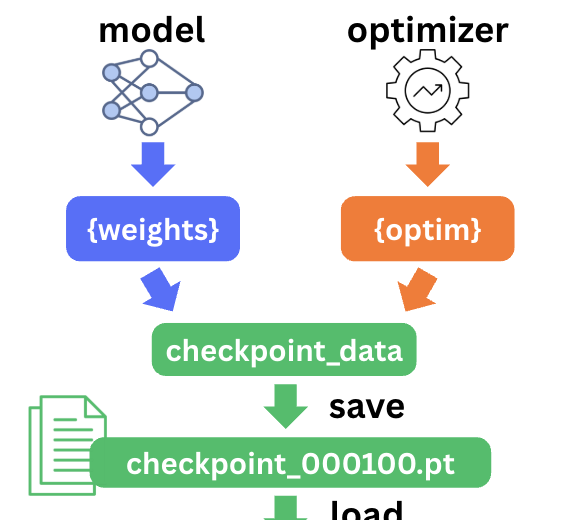

チェックポイントのファイルはあるステップごとに定期的に保存されます。

たくさんできるので、特定のディレクトリにまとめる必要があります。

今回は`checkpoints`という名前のディレクトリを作成して、そこに保存します。

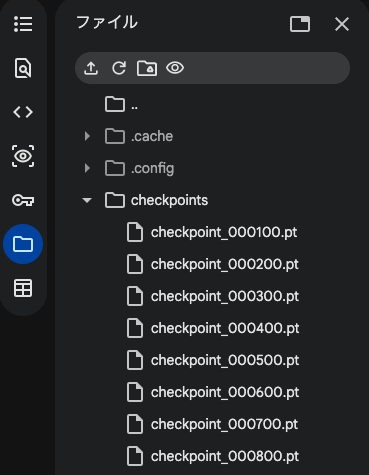

#### ▼ チェックポイント保存のケースのサンプル値

| 要素            | 意味                 |
| ------------- | ------------------ |
| `.`           | 現在のディレクトリ（今いるフォルダ） |
| `/`           | フォルダの区切り           |
| `checkpoints` | フォルダ名              |

**`./checkpoints` の意味**
→ **現在のディレクトリの中にある `checkpoints` フォルダ**


In [14]:
checkpoint_dir = "./checkpoints"

先ほどは100stepまで学習させました。

In [15]:
step = 100

```python
関数: os.makedirs
引数: ディレクトリパス checkpoint_dir, exist_ok=True
```

* `checkpoint_dir` に指定されたパスのディレクトリを作成します。
* `exist_ok=True` を指定すると、すでに同じディレクトリが存在していてもエラーになりません。

In [16]:
import os
os.makedirs(checkpoint_dir, exist_ok=True) # TODO: 関数(引数)

**`Check Point`** <label><input type="checkbox">左の📁をクリックして、`checkpoints`ディレクトリが作成されたことを確認した<label>

```python
出力: checkpoint_path（保存するチェックポイントファイルのパス）
関数: os.path.join
引数: checkpoint_dir, f"checkpoint_{step:06d}.pt"
```
- `f"checkpoint_{step:06d}.pt"`はファイル名です。例：checkpoint_000100.pt 
- `checkpoint_dir` とファイル名を結合して、保存先パスを作る。
- パスの名前を作成しただけであり、ptファイルの作成はこれからです。

In [17]:
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step:06d}.pt")  # TODO :出力 = 関数(引数)
print("checkpoint_path", checkpoint_path)

checkpoint_path ./checkpoints/checkpoint_000100.pt


**`Check Point`** <label><input type="checkbox">checkpoint_path ./checkpoints/checkpoint_000100.pt<label>

`checkpoint_data` は、**学習を再開するために必要な情報を1つにまとめた辞書**です。  
この辞書をあとで `torch.save(checkpoint_data, checkpoint_path)` のように保存します。

| キー | 中身 | 何に使う？ |
|---|---|---|
| `"weights"` | `model.state_dict()`（モデルの重み・バイアスなど） | **モデルの状態**を復元する |
| `"optim"` | `optimizer.state_dict()`（AdamWの内部状態など） | **最適化の状態**を復元して学習を続ける |


`model.state_dict()`にはモデルの重みやバイアスが保存されています。

ちょっと確認してみましょう。

In [18]:
print("model.state_dict()\n", model.state_dict())

model.state_dict()
 OrderedDict({'token_embedding_layer.token_embedding_table.weight': tensor([[ 0.1780, -0.0915, -0.3374,  ..., -1.8873, -0.4897,  1.0878],
        [ 0.4666, -1.1105, -0.8347,  ...,  0.1221, -0.3873, -0.4390],
        [-0.6022,  1.8276,  0.2967,  ...,  0.4005, -0.9785,  0.5160],
        ...,
        [-0.0094,  1.6586, -0.0950,  ..., -0.4595, -2.1591,  0.0718],
        [ 1.2176, -0.9310, -0.9483,  ..., -0.4745, -1.1020,  0.0747],
        [ 0.4318, -0.5778,  0.5908,  ...,  0.3869, -0.9794,  2.2251]],
       device='cuda:0'), 'blocks.0.layer_norm1.weight': tensor([0.9889, 1.0206, 0.9883, 1.0119, 0.9887, 1.0037, 0.9892, 0.9990, 0.9922,
        1.0015, 1.0064, 0.9886, 0.9935, 0.9994, 0.9869, 1.0224, 0.9945, 1.0325,
        1.0197, 1.0003, 0.9996, 1.0106, 0.9995, 0.9925, 1.0027, 0.9953, 1.0062,
        1.0096, 1.0010, 0.9875, 1.0195, 1.0211, 1.0085, 1.0130, 0.9848, 1.0152,
        0.9880, 0.9895, 0.9978, 0.9796, 1.0030, 0.9953, 0.9862, 1.0252, 0.9921,
        1.0131, 1.0124,

`optimizer.state_dict()`には、オプティマイザーの内部状態が保存されています。

こちらもちょっと確認してみましょう。

In [19]:
print("optimizer.state_dict()\n", optimizer.state_dict())

ストリーミング出力は最後の 5000 行に切り捨てられました。
        [2.5927e-11],
        [2.1925e-12],
        [6.4248e-12],
        [8.9682e-13],
        [1.3552e-11],
        [5.0252e-11],
        [3.5074e-13],
        [8.5210e-12],
        [5.1605e-12],
        [1.7700e-10],
        [1.5238e-12],
        [6.4335e-13],
        [1.0270e-11],
        [1.3436e-12],
        [2.5039e-13],
        [5.6839e-12],
        [4.5677e-12],
        [5.4149e-14],
        [5.7907e-13],
        [3.5273e-14],
        [1.5205e-11],
        [7.7583e-14],
        [4.5245e-10]], device='cuda:0')}, 39: {'step': tensor(101.), 'exp_avg': tensor([[ 1.5849e-06,  6.7151e-06, -7.6110e-06,  ..., -3.0413e-07,
         -7.6889e-07,  7.7044e-06],
        [ 2.7537e-06,  1.0316e-05,  3.4055e-07,  ..., -1.4303e-05,
         -1.7684e-05, -1.3505e-06],
        [-9.7333e-07, -1.0911e-05,  2.3028e-06,  ...,  6.5381e-06,
          8.8827e-06, -8.7509e-07],
        ...,
        [-7.5292e-07, -4.2667e-06, -1.8964e-06,  ..., -1.3813e-06,
         -5.104

それでは、この2つを1つにまとめた辞書として、`checkpoint_data`を作成します。

In [20]:
checkpoint_data = {"weights": model.state_dict(),
                   "optim": optimizer.state_dict()}
print("checkpoint_data", checkpoint_data)

ストリーミング出力は最後の 5000 行に切り捨てられました。
        [2.5927e-11],
        [2.1925e-12],
        [6.4248e-12],
        [8.9682e-13],
        [1.3552e-11],
        [5.0252e-11],
        [3.5074e-13],
        [8.5210e-12],
        [5.1605e-12],
        [1.7700e-10],
        [1.5238e-12],
        [6.4335e-13],
        [1.0270e-11],
        [1.3436e-12],
        [2.5039e-13],
        [5.6839e-12],
        [4.5677e-12],
        [5.4149e-14],
        [5.7907e-13],
        [3.5273e-14],
        [1.5205e-11],
        [7.7583e-14],
        [4.5245e-10]], device='cuda:0')}, 39: {'step': tensor(101.), 'exp_avg': tensor([[ 1.5849e-06,  6.7151e-06, -7.6110e-06,  ..., -3.0413e-07,
         -7.6889e-07,  7.7044e-06],
        [ 2.7537e-06,  1.0316e-05,  3.4055e-07,  ..., -1.4303e-05,
         -1.7684e-05, -1.3505e-06],
        [-9.7333e-07, -1.0911e-05,  2.3028e-06,  ...,  6.5381e-06,
          8.8827e-06, -8.7509e-07],
        ...,
        [-7.5292e-07, -4.2667e-06, -1.8964e-06,  ..., -1.3813e-06,
         -5.104

```python
関数: torch.save
引数: checkpoint_data, checkpoint_path
```

* 学習途中の状態を保存する **チェックポイント保存**によく使われます。

In [21]:
torch.save(checkpoint_data, checkpoint_path)    # TODO: 関数(引数)

**`Check Point`** <label><input type="checkbox">左の📁をクリックして、`checkpoints`ディレクトリの配下に、`checkpoint_000100.pt`ファイルが保存されたことを確認した<label>

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`makedirs`　`join`　`state_dict`　`save`　`weights`　`optim`　`load`　`torch.load`　`map_location`　`checkpoint_dir`　`checkpoint_data`

In [ ]:
########## NEW ##########
import os
def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.________(_____________, exist_ok=True)  # TODO: FILL

    checkpoint_path = os.path.____(  # TODO: FILL
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",  # TODO: FILL
    )

    checkpoint_data = {
        "weights": model._________(),  # TODO: FILL
        "optim": optimizer._________(),  # TODO: FILL
    }

    torch.____(checkpoint_data, checkpoint_path)  # TODO: FILL
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")
########## NEW ##########

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
########## NEW ##########
import os
def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "weights": model.state_dict(),
        "optim": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")
########## NEW ##########
```

</details>

In [22]:
########## NEW ##########
import os
def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "weights": model.state_dict(),
        "optim": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")
########## NEW ##########

ディレクトリ名を`checkpoints2`として、動作確認をします。

In [23]:
checkpoint_dir = "./checkpoints2"
step = 100
save_checkpoint(model, optimizer, checkpoint_dir, step)

[INFO] Successfully saved checkpoint at step 000100


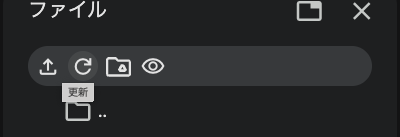

**`Check Point`**
1. <label><input type="checkbox"> 左のフォルダ📁 -> リロード🔄をクリックして、`checkpoints2` ディレクトリが作成されたことを確認した</label>
2. <label><input type="checkbox"> `checkpoints2` 配下に `checkpoint_000100.pt` ファイルが保存されたことを確認した</label>

## **Section3 Checkpointを再開する**

### チェックポイントを読み込む関数を定義する
CODE: `def load_checkpoint(model, optimizer, checkpoint_dir, step, device):`

**Mission: 保存済みファイルから学習状態を復元して、続きをそのまま走らせる！**

保存したチェックポイントを読み込めば、モデルの重みだけでなくoptimizerの内部状態も戻せるため、  
学習率やモーメンタムなどを含めて“中断前の続き”として再開できます。

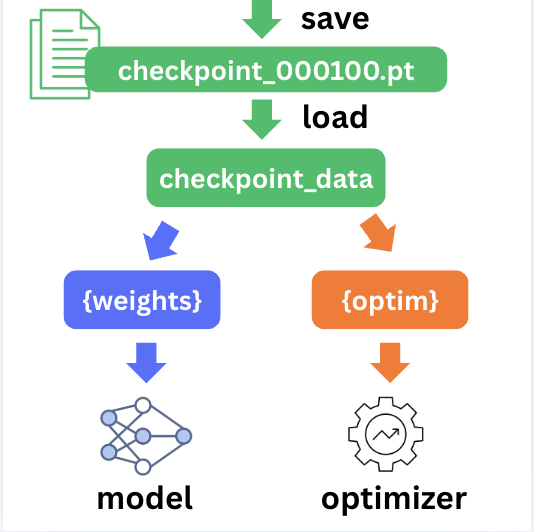

#### ▼ チェックポイント再開のケースのサンプル値

In [24]:
device_type = config.device_type
print("device_type", device_type)

device_type cuda


**`Check Point`** <label><input type="checkbox">device_type cuda<label>

```python
出力: checkpoint_path（読み込むチェックポイントファイルのパス）
関数: THINK_BY_YOURSELF
引数: checkpoint_dir, f"checkpoint_{step:06d}.pt"
```
- `checkpoint_dir` とファイル名を結合して、読み込み元パスを作る。
- パスの名前を作成しただけであり、ptファイルの読み込みはこれからです。

In [25]:
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step:06d}.pt")  # TODO: 出力 = 関数(引数)
print("checkpoint_path", checkpoint_path)

checkpoint_path ./checkpoints2/checkpoint_000100.pt


**`Check Point`** <label><input type="checkbox">checkpoint_path ./checkpoints/checkpoint_000100.pt<label>

```python
出力: checkpoint_data（読み込んだチェックポイントの辞書）
関数: torch.load
引数: checkpoint_path, map_location=device_type
```
- `checkpoint_path` からチェックポイントを読み込みます。
- `map_location` で読み込み先を指定します（`cpu` / `cuda`）。今回は `cuda`。

In [26]:
checkpoint_data = torch.load(checkpoint_path, map_location=device_type)  # TODO: 出力 = 関数(引数)
print("checkpoint_data", checkpoint_data)

ストリーミング出力は最後の 5000 行に切り捨てられました。
        [2.5927e-11],
        [2.1925e-12],
        [6.4248e-12],
        [8.9682e-13],
        [1.3552e-11],
        [5.0252e-11],
        [3.5074e-13],
        [8.5210e-12],
        [5.1605e-12],
        [1.7700e-10],
        [1.5238e-12],
        [6.4335e-13],
        [1.0270e-11],
        [1.3436e-12],
        [2.5039e-13],
        [5.6839e-12],
        [4.5677e-12],
        [5.4149e-14],
        [5.7907e-13],
        [3.5273e-14],
        [1.5205e-11],
        [7.7583e-14],
        [4.5245e-10]], device='cuda:0')}, 39: {'step': tensor(101., device='cuda:0'), 'exp_avg': tensor([[ 1.5849e-06,  6.7151e-06, -7.6110e-06,  ..., -3.0413e-07,
         -7.6889e-07,  7.7044e-06],
        [ 2.7537e-06,  1.0316e-05,  3.4055e-07,  ..., -1.4303e-05,
         -1.7684e-05, -1.3505e-06],
        [-9.7333e-07, -1.0911e-05,  2.3028e-06,  ...,  6.5381e-06,
          8.8827e-06, -8.7509e-07],
        ...,
        [-7.5292e-07, -4.2667e-06, -1.8964e-06,  ..., -1.3813e-06

`checkpoint_data['weights']`にはモデルの重みやバイアスが保存されています。

In [27]:
print("checkpoint_data['weights']\n", checkpoint_data['weights'])

checkpoint_data['weights']
 OrderedDict({'token_embedding_layer.token_embedding_table.weight': tensor([[ 0.1780, -0.0915, -0.3374,  ..., -1.8873, -0.4897,  1.0878],
        [ 0.4666, -1.1105, -0.8347,  ...,  0.1221, -0.3873, -0.4390],
        [-0.6022,  1.8276,  0.2967,  ...,  0.4005, -0.9785,  0.5160],
        ...,
        [-0.0094,  1.6586, -0.0950,  ..., -0.4595, -2.1591,  0.0718],
        [ 1.2176, -0.9310, -0.9483,  ..., -0.4745, -1.1020,  0.0747],
        [ 0.4318, -0.5778,  0.5908,  ...,  0.3869, -0.9794,  2.2251]],
       device='cuda:0'), 'blocks.0.layer_norm1.weight': tensor([0.9889, 1.0206, 0.9883, 1.0119, 0.9887, 1.0037, 0.9892, 0.9990, 0.9922,
        1.0015, 1.0064, 0.9886, 0.9935, 0.9994, 0.9869, 1.0224, 0.9945, 1.0325,
        1.0197, 1.0003, 0.9996, 1.0106, 0.9995, 0.9925, 1.0027, 0.9953, 1.0062,
        1.0096, 1.0010, 0.9875, 1.0195, 1.0211, 1.0085, 1.0130, 0.9848, 1.0152,
        0.9880, 0.9895, 0.9978, 0.9796, 1.0030, 0.9953, 0.9862, 1.0252, 0.9921,
        1.0131,

`checkpoint_data['optim']`にはオプティマイザの内部状態が保存されています。

In [28]:
print("checkpoint_data['optim']\n", checkpoint_data['optim'])

ストリーミング出力は最後の 5000 行に切り捨てられました。
        [2.5927e-11],
        [2.1925e-12],
        [6.4248e-12],
        [8.9682e-13],
        [1.3552e-11],
        [5.0252e-11],
        [3.5074e-13],
        [8.5210e-12],
        [5.1605e-12],
        [1.7700e-10],
        [1.5238e-12],
        [6.4335e-13],
        [1.0270e-11],
        [1.3436e-12],
        [2.5039e-13],
        [5.6839e-12],
        [4.5677e-12],
        [5.4149e-14],
        [5.7907e-13],
        [3.5273e-14],
        [1.5205e-11],
        [7.7583e-14],
        [4.5245e-10]], device='cuda:0')}, 39: {'step': tensor(101., device='cuda:0'), 'exp_avg': tensor([[ 1.5849e-06,  6.7151e-06, -7.6110e-06,  ..., -3.0413e-07,
         -7.6889e-07,  7.7044e-06],
        [ 2.7537e-06,  1.0316e-05,  3.4055e-07,  ..., -1.4303e-05,
         -1.7684e-05, -1.3505e-06],
        [-9.7333e-07, -1.0911e-05,  2.3028e-06,  ...,  6.5381e-06,
          8.8827e-06, -8.7509e-07],
        ...,
        [-7.5292e-07, -4.2667e-06, -1.8964e-06,  ..., -1.3813e-06

新しいモデルインスタンス`model2`を作成します。

モデル構造は先ほど学習した`model`と同じですが、パラメータ（重み・バイアスなど）は初期化されています。

In [29]:
model2 = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)

```python
インスタンス: model2（チェックポイントを読み込みたいモデル）
メソッド: load_state_dict
引数: checkpoint_data["weights"]（保存しておいたモデル重みの辞書）
```

- `model2` のパラメータ（重み・バイアスなど）を、`checkpoint_data["weights"]` の内容で**上書き更新**して復元します。

In [30]:
model2.load_state_dict(checkpoint_data["weights"])  # TODO: インスタンス.メソッド(引数)

<All keys matched successfully>

新しいオプティマイザーインスタンス`optimizer2`を作成します。

こちらも、元の`optimizer`と同じ構造ですが、内部状態（例: AdamWのモーメンタムや2次モーメント）は初期化されています。

In [31]:
optimizer2 = torch.optim.AdamW(model2.parameters())

```python
インスタンス: optimizer2（チェックポイントを読み込みたいoptimizer）
メソッド: load_state_dict
引数: THINK_BY_YOURSELF
```

- `optimizer2` の内部状態（例: AdamWのモーメンタムや2次モーメント）を、**上書き更新**して復元します。

In [32]:
optimizer2.load_state_dict(checkpoint_data["optim"])  # TODO: インスタンス.メソッド(引数)

In [33]:
trainer2 = Trainer(model2, optimizer2, data_loader, config)

学習を行います。train lossに着目すると、前回の100stepの学習完了時点から再開されていることがわかります。

In [34]:
trainer2.train()

step 00000 |  lr 1.000000e-03 |  train loss 4.4912 |  tok/s 170669 |  tokens 0 |  time 0.05s
step 00001 |  lr 9.910000e-04 |  train loss 4.3682 |  tok/s 182109 |  tokens 8,192 |  time 0.09s
step 00002 |  lr 9.820000e-04 |  train loss 4.4344 |  tok/s 184567 |  tokens 16,384 |  time 0.14s
step 00003 |  lr 9.730000e-04 |  train loss 4.4272 |  tok/s 184386 |  tokens 24,576 |  time 0.18s
step 00004 |  lr 9.640000e-04 |  train loss 4.3801 |  tok/s 177590 |  tokens 32,768 |  time 0.23s
step 00005 |  lr 9.550000e-04 |  train loss 4.4182 |  tok/s 184453 |  tokens 40,960 |  time 0.27s
step 00006 |  lr 9.460000e-04 |  train loss 4.3450 |  tok/s 183865 |  tokens 49,152 |  time 0.32s
step 00007 |  lr 9.370000e-04 |  train loss 4.3661 |  tok/s 184238 |  tokens 57,344 |  time 0.36s
step 00008 |  lr 9.280000e-04 |  train loss 4.3288 |  tok/s 177868 |  tokens 65,536 |  time 0.41s
step 00009 |  lr 9.190000e-04 |  train loss 4.4039 |  tok/s 184277 |  tokens 73,728 |  time 0.45s
step 00010 |  lr 9.100000e

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`os`　`path`　`join`　`torch`　`load`　`save`　`checkpoint_data`　`load_state_dict`　`state_dict`　`weights`　`optim`　`f"checkpoint_{step:06d}.pt"`　`step`　`device`　`model`　`optimizer`

In [ ]:
########## NEW ##########
def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.____(  # TODO: FILL
        checkpoint_dir,
        ______________________,  # TODO: FILL
    )

    checkpoint_data = torch.____(checkpoint_path, map_location=device)  # TODO: FILL
    model._______________(checkpoint_data["_______"])  # TODO: FILL
    optimizer._______________(checkpoint_data["_____"])  # TODO: FILL

    print(f"[INFO] Resume completed at step {step}")
########## NEW ##########

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
########## NEW ##########
def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_data["weights"])
    optimizer.load_state_dict(checkpoint_data["optim"])

    print(f"[INFO] Resume completed at step {step}")
########## NEW ##########
```

</details>

In [35]:
########## NEW ##########
def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(  # TODO: FILL
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",  # TODO: FILL
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)  # TODO: FILL
    model.load_state_dict(checkpoint_data["weights"])  # TODO: FILL
    optimizer.load_state_dict(checkpoint_data["optim"])  # TODO: FILL

    print(f"[INFO] Resume completed at step {step}")
########## NEW ##########

以下の設定で、動作確認をしてみましょう。

In [36]:
checkpoint_dir = "./checkpoints2"
step = 100
device = "cuda"
load_checkpoint(model2, optimizer2, checkpoint_dir, step, device)

[INFO] Resume completed at step 100


**`Check Point`** <label><input type="checkbox">[INFO] Resume completed at step 100<label>

## **Section 4: Trainerクラスの更新**

Trainerクラスに、先ほどの`save_checkpoint`関数と、`load_checkpoint`関数を組み込みます。

`checkpoint_save_frequency`ごとに、チェックポイントを保存する設定にします。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`checkpoint_dir`　`start_step`　`save_checkpoint`　`load_checkpoint`　`total_training_steps`　`time`　`checkpoint_path`　`checkpoint_data`　`start_epoch`　`save_model`　`1`　`2`

In [ ]:
import time

class Trainer:
    """DELETE
    def __init__(self, model, optimizer, data_loader, config):
    """
    ########## NEW ##########
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, start_step=0):  # TODO: FILL
    ########## NEW ##########
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        ########## NEW ##########
        self.checkpoint_dir = ______________  # TODO: FILL
        self.start_step = __________  # TODO: FILL
        ########## NEW ##########
        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        ########## NEW ##########
        if self.__________ > 0:  # TODO: FILL
            ______________(self.model, self.optimizer, self.______________, self.__________, self.config.device_type)  # TODO: FILL
        ########## NEW ##########

        total_train_time = 0
        last_log_time = time.time()

        # (configで指定された回数+1)だけtrain_stepを実行する。
        """DELETE
        for step in range(self.config.total_training_steps+1):
        """
        ########## NEW ##########
        for step in range(self.start_step+__, self.config.total_training_steps+1):  # TODO: FILL
        ########## NEW ##########
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            ########## NEW ##########
            if step % self.config.checkpoint_save_frequency == 0:
                _______________(self.model, self.optimizer, self.______________, step)  # TODO: FILL
            ########## NEW ##########

            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
import time

class Trainer:
    """DELETE
    def __init__(self, model, optimizer, data_loader, config):
    """
    ########## NEW ##########
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, start_step=0):
    ########## NEW ##########
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        ########## NEW ##########
        self.checkpoint_dir = checkpoint_dir
        self.start_step = start_step
        ########## NEW ##########
        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        ########## NEW ##########
        if self.start_step > 0:
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)
        ########## NEW ##########

        total_train_time = 0
        last_log_time = time.time()

        # (configで指定された回数+1)だけtrain_stepを実行する。
        """DELETE
        for step in range(self.config.total_training_steps+1):
        """
        ########## NEW ##########
        for step in range(self.start_step+1, self.config.total_training_steps+1):
        ########## NEW ##########
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            ########## NEW ##########
            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)
            ########## NEW ##########

            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time
```

</details>

In [37]:
import time

class Trainer:
    """DELETE
    def __init__(self, model, optimizer, data_loader, config):
    """
    ########## NEW ##########
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, start_step=0):
    ########## NEW ##########
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        ########## NEW ##########
        self.checkpoint_dir = checkpoint_dir
        self.start_step = start_step
        ########## NEW ##########
        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        ########## NEW ##########
        if self.start_step > 0:
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)
        ########## NEW ##########

        total_train_time = 0
        last_log_time = time.time()

        # (configで指定された回数+1)だけtrain_stepを実行する。
        """DELETE
        for step in range(self.config.total_training_steps+1):
        """
        ########## NEW ##########
        for step in range(self.start_step+1, self.config.total_training_steps+1):
        ########## NEW ##########
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            ########## NEW ##########
            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)
            ########## NEW ##########

            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

## **Section 5. モデルの学習**

Configクラスにcheckpintの保存間隔を追加します。

まずは、100stepごとに保存する設定にしてみてください。

今回は本番学習ではなく動作確認目的ですので、効率的に学習する必要はありません。

そのため、warmup_stepsを0とします。



In [43]:
# モデル設定を保存する設定クラス
class Config:
    batch_size = 16
    input_sequence_length = 512
    max_learning_rate = 1e-3
    min_learning_rate = 1e-4
    warmup_steps = 0 # 1_000
    ############ NEW ############
    total_training_steps = 200  # およそ1分
    ############ NEW ############
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    ############ NEW ############
    checkpoint_save_frequency = 100  # TODO: チェックポイント保存の頻度
    ############ NEW ############
    learning_rate = 2e-3  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 256  # 埋め込み次元数
    hidden_dim = 1024
    num_attention_heads = 4  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    num_relative_positions = 128 # 相対位置が考慮する範囲
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [44]:
# 設定を読み込みシードを設定する
config = Config()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

新しいモデルインスタンスとして、`model3`を作成します。

In [54]:
model3 = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)

In [55]:
# 学習率を指定せずに、optimizerインスタンスを作成します。
optimizer3 = torch.optim.AdamW(model3.parameters())

### 🚀 学習スタート！


- **設定**: `checkpoint_save_frequency = 100` / `total_training_steps = 200`
- **目安**: 約1分（T4 GPU）

ログを見て、**step100** と **step200** でチェックポイントが **2回保存** されたことを確認しよう。

In [56]:
"""DELETE
trainer = Trainer(model, optimizer, data_loader, config)
"""
trainer3 = Trainer(model3, optimizer3, data_loader, config, start_step=0, checkpoint_dir="./checkpoints3")

In [57]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer3.train()

===トレーニングが正常に開始されました===
step 00001 |  lr 9.970000e-04 |  train loss 10.9291 |  tok/s 178657 |  tokens 8,192 |  time 0.05s
step 00002 |  lr 9.940000e-04 |  train loss 10.0613 |  tok/s 196280 |  tokens 16,384 |  time 0.09s
step 00003 |  lr 9.910000e-04 |  train loss 9.5029 |  tok/s 199119 |  tokens 24,576 |  time 0.13s
step 00004 |  lr 9.880000e-04 |  train loss 9.1319 |  tok/s 199891 |  tokens 32,768 |  time 0.17s
step 00005 |  lr 9.850000e-04 |  train loss 8.8936 |  tok/s 198752 |  tokens 40,960 |  time 0.21s
step 00006 |  lr 9.820000e-04 |  train loss 8.4661 |  tok/s 200026 |  tokens 49,152 |  time 0.25s
step 00007 |  lr 9.790000e-04 |  train loss 8.1417 |  tok/s 201626 |  tokens 57,344 |  time 0.29s
step 00008 |  lr 9.760000e-04 |  train loss 7.7974 |  tok/s 201094 |  tokens 65,536 |  time 0.33s
step 00009 |  lr 9.730000e-04 |  train loss 7.4946 |  tok/s 201381 |  tokens 73,728 |  time 0.37s
step 00010 |  lr 9.700000e-04 |  train loss 7.2419 |  tok/s 200438 |  tokens 81,920 |  time 0

`total_training_steps`を200から300に増やして、**200step**から再開してみます。

In [58]:
config.total_training_steps = 300

In [59]:
trainer4 = Trainer(model3, optimizer3, data_loader, config, start_step=200, checkpoint_dir="./checkpoints3") # TODO: THINK_BY_YOURSELF

In [60]:
trainer4.train()

[INFO] Resume completed at step 200
step 00201 |  lr 3.970000e-04 |  train loss 3.8822 |  tok/s 180286 |  tokens 1,646,592 |  time 0.05s
step 00202 |  lr 3.940000e-04 |  train loss 4.0815 |  tok/s 188800 |  tokens 1,654,784 |  time 0.09s
step 00203 |  lr 3.910000e-04 |  train loss 3.8659 |  tok/s 190114 |  tokens 1,662,976 |  time 0.13s
step 00204 |  lr 3.880000e-04 |  train loss 3.8707 |  tok/s 189244 |  tokens 1,671,168 |  time 0.18s
step 00205 |  lr 3.850000e-04 |  train loss 3.9898 |  tok/s 188989 |  tokens 1,679,360 |  time 0.22s
step 00206 |  lr 3.820000e-04 |  train loss 3.9495 |  tok/s 189470 |  tokens 1,687,552 |  time 0.26s
step 00207 |  lr 3.790000e-04 |  train loss 3.8517 |  tok/s 190427 |  tokens 1,695,744 |  time 0.30s
step 00208 |  lr 3.760000e-04 |  train loss 3.7752 |  tok/s 163428 |  tokens 1,703,936 |  time 0.35s
step 00209 |  lr 3.730000e-04 |  train loss 3.7776 |  tok/s 190158 |  tokens 1,712,128 |  time 0.40s
step 00210 |  lr 3.700000e-04 |  train loss 3.9820 |  t

**`Check Point`**
1. <label><input type="checkbox"> 201step から再開されたことを確認した</label>
2. <label><input type="checkbox"> config に設定された通り、300step で学習が完了したことを確認した</label>

201step から再開されていなかった場合、Trainerクラスの穴埋めをもう一度確認してください。

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 26: Checkpoint** <label><input type="checkbox"> Mark as Done</label>